In [1]:
from transformers import GPT2LMHeadModel

/Users/kshitijdesai/Documents/Personal/GPT-2-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124 M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16610.66it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [ ]:
# first 20 weights
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

Matplotlib is building the font cache; this may take a moment.


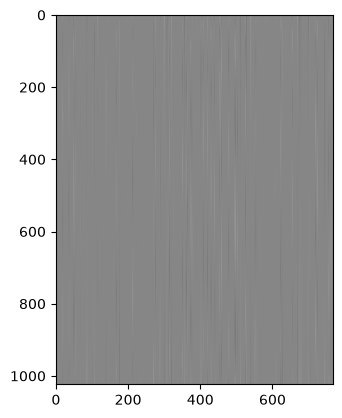

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap = "gray")

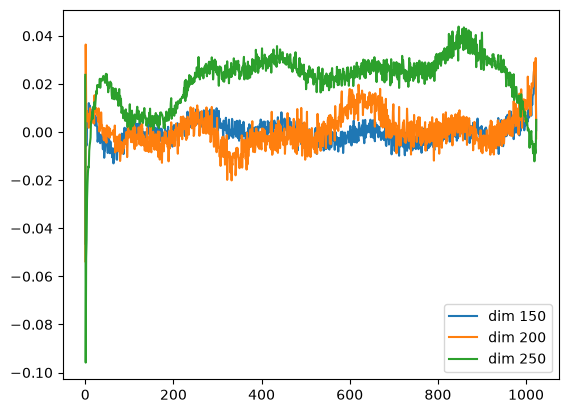

In [11]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150], label="dim 150") # 150th dimension embedding across all positions
plt.plot(sd_hf["transformer.wpe.weight"][:, 200], label = "dim 200") # 200th dimension embedding across all positions
plt.plot(sd_hf["transformer.wpe.weight"][:, 250], label = "dim 250") # 250th dimension embedding across all positions

plt.legend()
plt.show()

In [14]:
sd_hf["transformer.h.1.attn.c_attn.weight"].shape

torch.Size([768, 2304])

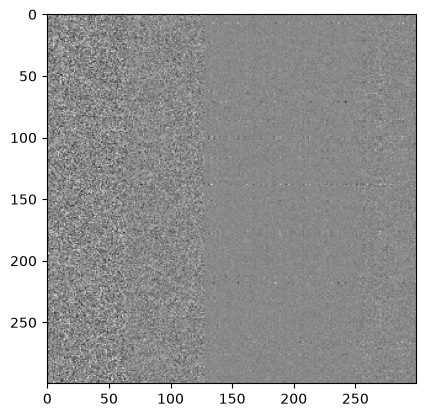

In [15]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300], cmap="gray")

In [16]:
from transformers import pipeline, set_seed

generator = pipeline("text-generation", model="gpt2")
set_seed(42)
generator("Hello, I'm a language model", max_length = 30, num_return_sequences = 5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18541.68it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outp

[{'generated_text': "Hello, I'm a language modeler, I am not a programmer. I'm a writer. I'm a teacher. I am a translator. I'm a programmer. I'm a modeler. I'm a teacher. I'm a translator. I'm a modeler. And I'm a writer.\n\nYes, I'm a writer. Yes, I'm a writer.\n\nAnd I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. I'm a translator. And I'm a translator. I'm a translator. And I'm a translator. And I'm a translator.\n\nOh, yes. And I'm a translator. I'm a translator. I'm a translator. I'm a translator. And I'm a translator. And I'm a translator. I'm a translator. I'm a translator. And I'm a translator. And I'm a translator. I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a translator. And I'm a"},
 {'generated_text': "Hello, I'm a language modeler. I'm a language modeler, and I